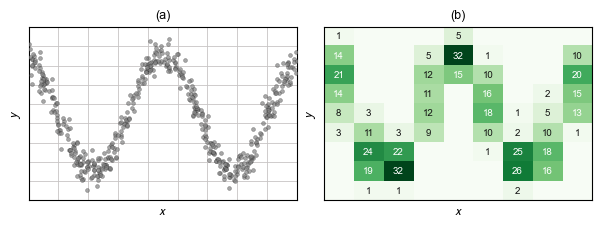

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ACCENT = "#117738"      # cor de destaque
GRID = "#c7c4c4"        # cor das linhas da grade
N_DIV = 9               # numero de celulas por eixo
N_PTS = 500             # numero de pares observados
SEED = 2
rng = np.random.default_rng(SEED)

lo, hi = -3, 3
edges = np.linspace(lo, hi, N_DIV + 1)
centros = (edges[:-1] + edges[1:]) / 2

# Pares observados
x = rng.uniform(lo, hi, N_PTS)
y = 2 * np.cos(2.0 * x) + rng.normal(0, 0.3, N_PTS)

plt.rcParams.update({"font.family": "Arial", "mathtext.fontset": "stixsans",
                     "axes.titlesize": 9, "axes.labelsize": 9,
                     "xtick.labelsize": 9, "ytick.labelsize": 9})
cm = 1/2.54
fig, axes = plt.subplots(1, 2, figsize=(15*cm, 5.5*cm), layout="constrained")

# ----------------------------------------------------------------------
# Painel (a): pares observados sobre a grade
# ----------------------------------------------------------------------
ax = axes[0]
for g in edges:
    ax.plot([lo, hi], [g, g], color=GRID, lw=0.6, zorder=1)
    ax.plot([g, g], [lo, hi], color=GRID, lw=0.6, zorder=1)
ax.scatter(x, y, c='gray', s=8, alpha=0.7, edgecolors='black', linewidth=0.2, zorder=3)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("(a)")
ax.set_xticks([])
ax.set_yticks([])

# ----------------------------------------------------------------------
# Painel (b): contagem por celula, formando p(x,y)
# ----------------------------------------------------------------------
ax = axes[1]
H, _, _ = np.histogram2d(x, y, bins=[edges, edges])
H = H.T
ax.imshow(H, cmap="Greens", origin="lower", extent=[lo, hi, lo, hi], aspect="auto")
for i, yc in enumerate(centros):
    for j, xc in enumerate(centros):
        c = int(H[i, j])
        if c > 0:
            cor = "white" if c > H.max() * 0.4 else "#131313"
            ax.text(xc, yc, str(c), ha="center", va="center", fontsize=7, color=cor)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("(b)")
ax.set_xticks([])
ax.set_yticks([])

fig.savefig("figuras/exemplo_informacao_mutua.png", dpi=300)